# TP6 A short introduction to neural networks with Keras

We will use the ***Keras library***, which serves as a high-level API for TensorFlow (or Pytorch or Jax).

 Keras is a
deep-learning framework for Python that provides a convenient way to define and
train almost any kind of deep-learning model. Keras was initially developed for
researchers, with the aim of enabling fast experimentation.
Keras has the following key features:
- It allows the same code to run seamlessly on CPU or GPU.
- It has a user-friendly API that makes it easy to quickly prototype deep-learning
models.
- It has built-in support for convolutional networks (for computer vision), recurrent
networks (for sequence processing), and any combination of both.
- It supports arbitrary network architectures: multi-input or multi-output models,
layer sharing, model sharing, and so on.

Extracted from the book "Deep Learning with Python ", author : François Chollet.



About the use of Tensorflow here :
 **Keras 3** supports multiple backends, including **TensorFlow** and **PyTorch**. You can also use **JAX**.

You choose **one backend at a time**, such as `"tensorflow"` or `"torch"`, before importing `keras`.

### Example: Pytorch backend

```python
import os
os.environ["KERAS_BACKEND"] = "torch"

Q1.  What is an MLP?

An **MLP** is a **multilayer perceptron**.

In modern language, an MLP is a **fully connected feedforward neural network**.

- **Feedforward** means information moves from the input layer to the output layer, without loops or recurrence (unlike a RNN, where "R" is for "recurrent").
- **Fully connected** means every neuron in one layer is connected to every neuron in the next layer (unlike  a CNN)
- **Multilayer** means there is at least one **hidden layer** between the input and the output.




Example of a CNN :
https://en.wikipedia.org/wiki/Convolutional_neural_network#/media/File:1D_Convolutional_Neural_Network_feed_forward_example.png

Example of a RNN : https://en.wikipedia.org/wiki/Recurrent_neural_network#/media/File:Recurrent_neural_network_unfold.svg

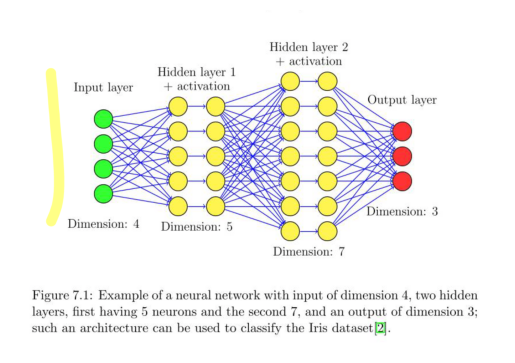

In [ ]:
#  MLP : an example (from M. Turinici)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("figure_MLP_cours.png")
plt.imshow(img)
plt.axis("off")
plt.show()

This tutorial uses the Fashion MNIST dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels). We will only use  an MLP.

 Fashion MNIST  is a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected.

For Fashion MNIST,  ***60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images***.

In [1]:
import os
import keras
import numpy as np

os.environ["KERAS_BACKEND"] = "tensorflow"

keras.utils.set_random_seed(42)
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let us take a look at the shape and the datatype of the training set :

In [ ]:
X_train.shape, X_train.dtype

((60000, 28, 28), dtype('uint8'))

We will need a validation set during training. As the dataset is already shuffled, we will just use the last rows of the dataset for the validation set :

In [2]:
X_val, y_val = X_train[-5000:], y_train[-5000:]
X_train, y_train = X_train[:-5000], y_train[:-5000]

Neural networks operate best when inputs are on a moderate scale. If the input values are large integers, training can become less stable and may converge more slowly. For this reason, it is standard practice to normalize pixel values before training. There is no universally optimal scaling rule for every problem, but some form of scaling is usually necessary.

A natural starting point for grayscale images is to rescale pixel values to the interval ([0,1]). In practice, this means first converting the data from unsigned integers to floating-point numbers, and then dividing each pixel value by the maximum possible value.

If the first layer uses a sigmoid or tanh activation, keeping the input values small becomes even more important, since large inputs may drive the activations into their saturation regime (Q : what is saturation ?)

In [3]:
X_train01, X_val01, X_test01 = X_train/255.0, X_val/255.0,  X_test/255.0

 **Remark.** Input normalization and proper weight initialization are especially important in **deep** learning, where poor scaling can contribute to issues such as **vanishing gradients** and **exploding gradients**. In the present setting, the network is **shallow**, so these difficulties are less severe. Nevertheless, the scale of both the inputs and the weights still matters, even if the associated optimization problems are less pronounced.

Here are  the class names :

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Q2. What does the first image of the training set represent ?

In [ ]:
class_names[y_train[0]]

'Ankle boot'

Let us display the first 25 images in the training set :

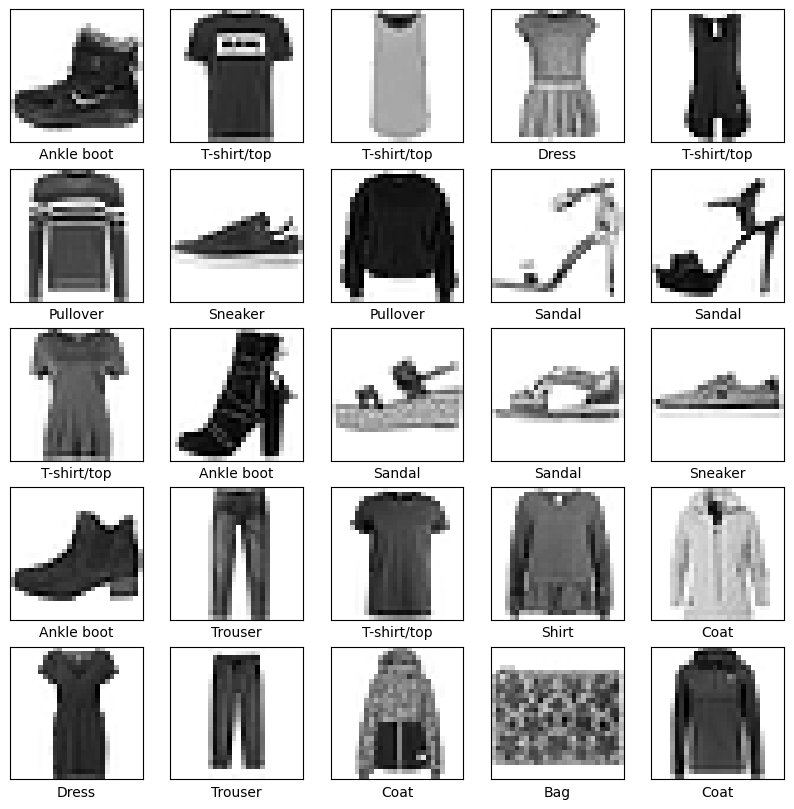

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()


Now let us build the neural network. Here we will build a classification MLP (multi layer perceptron).  

In [4]:
model = keras.Sequential([
    keras.layers.Input(shape=[28,28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(100,activation="relu",kernel_initializer="he_normal"),
    keras.layers.Dense(10,activation="softmax"),
])

Q3.
 a) What does the  `Flatten` layer do ?

 b) What do the numbers 300, 100 and 10 represent ?

 c) How many hidden layers are there ?

     
 d) Why do we use the softmax activation function in the output layer  and what do the outputs of the last layer represent ?

 e) What does "sequential" mean ?

Well, it depends...

In practice the word **sequential** is used in at least two ways:

1. **Strict mathematical sense**
   A model of the form
   $$
   x \mapsto f_n(\cdots f_2(f_1(x))\cdots)
   $$
   with no loops.

   In other words : A **sequential** model, in a mathematical language, means that the layers are arranged in a simple linear chain,

$$
x \to f_1 \to f_2 \to \cdots \to f_n.
$$
   In that mathematical sense, **sequential implies feedforward**.

2.
**Software meaning:** the word “sequential” can be a bit loose.
   For example, a `Sequential` container in a library may just mean “stacked layers one after another.”
   But one of those layers could itself be recurrent (such as an LSTM layer) so  it is not sequential in the mathematical sense of the term.

  



Differences between feedforward and sequential (software meaning) :

For example, a network with **skip connections**, **multiple branches**, or **multiple inputs** can still be **feedforward** as long as there is no cycle, but it is **no longer a simple sequential stack**.

***skip connections*** : https://upload.wikimedia.org/wikipedia/commons/b/ba/ResBlock.png

***multiple branches*** : next cell



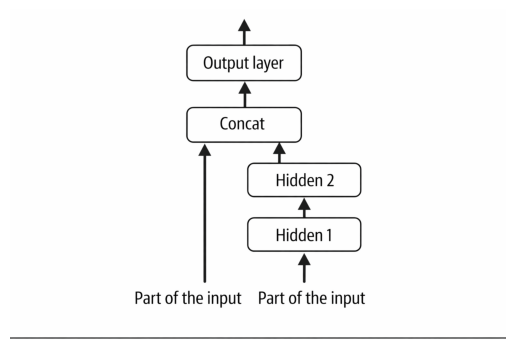

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("Multiple_branches.png")
plt.imshow(img)
plt.axis("off")
plt.show()

The model's summary() method displays all the model's layers :

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Q4.  What does 235,500 correspond to ?

Q5. What is a "non trainable" parameter ?

In [ ]:
784*300+300

235500

Q6. Display the weights and the biases of the first hidden layer.

In [ ]:
# Answer for Q6.
weights, biases = model.layers[1].get_weights()
weights

array([[-0.02708957, -0.01657043, -0.02541305, ..., -0.0117284 ,
        -0.07759066, -0.04104815],
       [ 0.03956839,  0.03968426,  0.11159597, ...,  0.00709551,
         0.10016222,  0.00951595],
       [ 0.0368086 , -0.00992455,  0.00582458, ..., -0.05939535,
         0.00859205,  0.04936637],
       ...,
       [ 0.0014246 , -0.04466628,  0.00846922, ..., -0.05190999,
         0.03495238,  0.05571212],
       [ 0.00618674,  0.00718611, -0.04097459, ..., -0.04273593,
         0.03054574, -0.05612838],
       [ 0.02281788,  0.00126068, -0.07944933, ...,  0.08006408,
        -0.02017345,  0.07210501]], dtype=float32)

In [ ]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.



Q7.

a)  **Why don't we initialize all the weights to zero (as is done with the biases) ?**

b) **What happens if we initialize all the weights and the biases of a layer with the same value ?**

Answer provided during the session.


The initialization is usually random : the weights  are sampled from a normal distribution or a uniform distribution, usually independently. In particular in  the context of deep learning, the variances of these normal distributions are important to keep a relatively constant scale (see Kaiming He's paper for more info) and to avoid the "vanishing gradient problem" and the "exploding gradient problem" (more info in the Exercise sheet).

Remarks : when you create a multilayer perceptron (MLP) using Keras, each dense layer by default uses the Glorot Uniform initializer for its weight matrix  and initializes the biases to zeros.
You can always override these defaults by specifying a different initializer in the layer's constructor if needed. Actually here, as we used  a ReLU activation, we used the "He" intializer (it does not matter that much to use "He" or "Gloriot" here as the network is shallow. However, even for a shallow network,  it is important for the weights not to be far too small or far too large.)( See exercise 2 for He initialization in the one-dimensional case)

See also :

https://www.deeplearning.ai/ai-notes/initialization/index.html



Now we need to "compile the model" : it means we will specify the loss function and the optimizer we use. Optionally, you can specify a list of extra metrics to compute during training and evaluation.  

In [5]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

We used the  `sparse_categorical_crossentropy` loss because we have "sparse labels" : for each instance, there is just a target class index : from 0 to 9. If instead we had one-hot vectors ( e.g. [0,0,1,0,0,0,0,0,0,0] to represent class 2), then we would need to use the "categorical_cross_entropy" loss instead.

Since it is a classifier, it is useful to measure its accuracy during training and evaluation, which is why we set `metrics=["accuracy"]`. You can find the list of metrics proposed by keras here : https://www.tensorflow.org/api_docs/python/tf/keras/metrics

Q8. What loss would we have chosen if we had a binary classification problem ? See : https://www.tensorflow.org/api_docs/python/tf/keras/losses

Q9. What basic loss could we use for a regression problem ?


Now the model is ready to be trained. For this we simply need to call its `fit` method :

In [6]:
history = model.fit(X_train01, y_train, epochs = 60, validation_data=(X_val01, y_val))

Epoch 1/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8275 - loss: 0.4816 - val_accuracy: 0.8318 - val_loss: 0.4261
Epoch 2/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8666 - loss: 0.3632 - val_accuracy: 0.8406 - val_loss: 0.3980
Epoch 3/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8813 - loss: 0.3224 - val_accuracy: 0.8506 - val_loss: 0.3803
Epoch 4/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8895 - loss: 0.2981 - val_accuracy: 0.8510 - val_loss: 0.3903
Epoch 5/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8976 - loss: 0.2783 - val_accuracy: 0.8658 - val_loss: 0.3540
Epoch 6/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9012 - loss: 0.2636 - val_accuracy: 0.8734 - val_loss: 0.3528
Epoch 7/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9075 - loss: 0.2489 - val_accuracy: 0.8682 - val_loss: 0.3701
Epoch 8/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9111 - loss: 0.2

Remark : if you call the fit method again, keras continues the training where it left off.


Q10. Can you recall what is an "epoch" ?

Q11. The `fit()` method also has the two arguments  `class_weight` and `sample_weight` (not used here).   When can these arguments  be useful ?

The `fit()` method returns a History object containing in particular a dictionary (`history.history`) containing the loss and extra metrics it measured at the end of each epoch on the training set and on the validation set (if any). Let us display the learning curves.

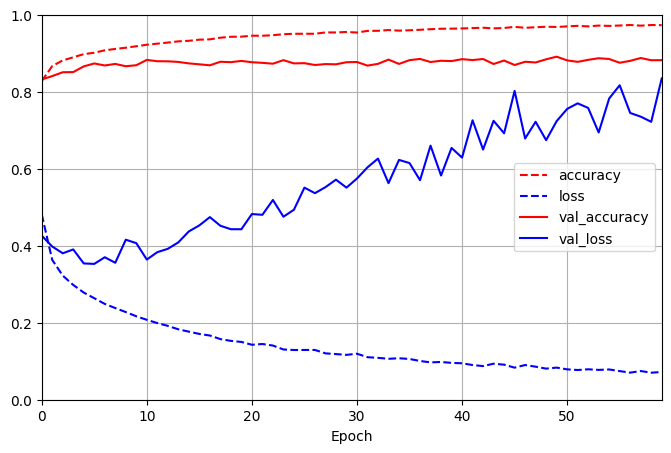

In [11]:
import pandas as pd
pd.DataFrame(history.history).plot(
    figsize=(8,5),xlim=[0,59],ylim=[0,1],grid=True, xlabel="Epoch",
    style=["r--", "b--", "r", "b"]
)
plt.show()

Q12. Four values are displayed : "accuracy", "loss", "val_accuracy" and "val_loss". Can you tell precisely what each value represents ?

Q13. Comment the curves.

Remark : if we kept increasing the number of epochs, we would end up with a training loss close to zero  and a training accuracy close to 100%. More precisely, after about 150 epochs, we get the following values
-  validation loss : about 1.4
- training loss : about 0.03
- validation accuracy : about 89%
- training accuracy : about 99%




---

**Answer.** The training loss keeps decreasing, whereas the validation loss first decreases and then starts increasing. In addition, the training accuracy is slightly higher than the validation accuracy, and the gap appears to be meaningful. These two observations are typical signs of **overfitting**.

**General definition of overfitting.** Overfitting occurs when a machine learning model performs better on the training data than on new, previously unseen data. In that case, the model does not only learn the relevant underlying patterns; it also learns noise or dataset-specific details that do not generalize well. As a result, its performance on new data deteriorates.

In the present case, the kind of overfitting we observe does not seem to reduce the validation **accuracy** very much, so if one only cares about classification accuracy, the practical impact may be limited. However, it still degrades the quality of the predicted probabilities, as reflected by the increase in validation **loss**. Moreover, training for 60 epochs instead of 10 would therefore amount to a substantial waste of time and computational resources.

The validation cross-entropy loss increases mainly because this loss depends on the predicted probabilities, whereas accuracy only checks whether the predicted class is correct, that is, whether the class with highest predicted probability coincides with the true class.

Recall that cross-entropy measures the quality of the estimated probabilities: the outputs of the model are interpreted as class probabilities, and these probabilities encode the model’s confidence in its predictions.

Thus, even if the model continues to classify most validation examples correctly, which keeps the validation accuracy roughly constant, the cross-entropy loss can still increase because it strongly penalizes badly calibrated predictions. With overfitting, the model becomes increasingly confident on the training set, where it has effectively adapted to many dataset-specific details. On new images, when it makes a mistake, it may do so with excessive confidence; this leads to a large contribution to the loss. In other words, the model may be wrong for reasons tied to superficial or irrelevant features that happened to be useful on the training set but do not generalize.

If the model is trained for many epochs, the training accuracy may continue to increase and can even approach 100%. In that regime, the model is no longer merely learning robust predictive structure; it is also fitting idiosyncratic details of the training images (i.e. peculiar details that happen to be present only in the training set)(e.g.  "presence of grass because dogs'photos in the training set are only outside"). This is why the **training** accuracy is not a reliable measure of true predictive performance: it can be far too optimistic, especially for highly overparameterized models.

**Final remark.** More generally, the cross-entropy loss can be interpreted as measuring how well the model estimates the conditional probabilities
$$
\eta_j(x)=P(Y=j\mid X=x), \qquad j=1,\dots,K,
$$
when there are $K$ classes. For a given input $x$, the model outputs estimates of the vector $(\eta_j(x))_{1\le j\le K}$.

In many applications, $Y$ is not a deterministic function of $X$, so the quantities $\eta_j(x)$ are not simply equal to 0 or 1. For example, when predicting a disease from a few biological markers, even the optimal prediction rule may remain uncertain. In such situations, it is entirely possible to have a model that is not especially accurate as an estimator of the probabilities $\eta_j(x)$, while still being a fairly good classifier. Indeed, classification only depends on which class has the largest estimated probability; as long as the prediction stays on the correct side of the decision boundary, the classification is correct, even if the confidence is poorly estimated.

So, in general, estimating the conditional probabilities well is a harder task than classifying well. From this perspective, overfitting may significantly damage the estimation of the probabilities $(\eta_j(x))_{1\le j\le K}$, even when its effect on classification accuracy is small.






The  cross-entropy loss for the validation set increases mostly because  this loss uses the probabilities (the outputs of the model) while the accuracy only checks whether the prediction is correct (i.e., if the class with the highest probability is the true class).

Remember that the cross-entropy loss  measures the certainty of the predictions : this loss uses the outputs of the model, those outputs  are supposed to be probabilities, these probabilities represent the confidence the model has in its prediction.

Even if the model classifies most examples correctly (which keeps the validation accuracy constant), the cross-entropy loss heavily penalizes  poorly calibrated predictions. With overfitting, the model “memorizes” many details of the training data,  and becomes increasingly confident in its predictions on that set.  When seeing a new image, when it gets wrong, as it is "overly confident" while being wrong, the loss increases (this  badly classified image certainly "looks like" some images that are in the training set and that do not have the same label,  but it looks like them mostly in relation to unrelevant details ("a cat outside").

The training accuracy keeps increasing if we train the model long enough (up to almost 100%) : the images in the training set that the model ends up   classifying correctly  if we let it train for a lot of epochs, it just "learns them by heart" : it learns unrelevant details related to those specific images. That is why this **training** accuracy is not "reliable" (can be far too optimistic, especially with overparametrized models).




Q14. a) Find the indices, for the first 200 rows of the validation set, where the model (that we trained for 60 epochs) is wrong.


In [17]:
probas_val_60=model.predict(X_val01[:200])
classif_val_60=probas_val_60.argmax(axis=1)
wrong_classif_60=(classif_val_60!=y_val[:200])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


b) Now let us train the model for only 10 epochs and call this model `model_10`.

In [13]:
model_10 = keras.Sequential([
    keras.layers.Input(shape=[28,28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(100,activation="relu",kernel_initializer="he_normal"),
    keras.layers.Dense(10,activation="softmax"),
])
model_10.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model_10.fit(X_train01, y_train, epochs=10, validation_data=(X_val01, y_val))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8266 - loss: 0.4806 - val_accuracy: 0.8326 - val_loss: 0.4162
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8661 - loss: 0.3646 - val_accuracy: 0.8512 - val_loss: 0.3772
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8797 - loss: 0.3260 - val_accuracy: 0.8534 - val_loss: 0.3804
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8890 - loss: 0.2993 - val_accuracy: 0.8718 - val_loss: 0.3514
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8955 - loss: 0.2808 - val_accuracy: 0.8722 - val_loss: 0.3455
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9014 - loss: 0.2658 - val_accuracy: 0.8758 - val_loss: 0.3535
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9055 - loss: 0.2512 - val_accuracy: 0.8692 - val_loss: 0.3759
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9097 - loss: 0.2

So the accuracy on the validation set is almost the same with 10 epochs as with 60 epochs (stagnant val accuracy, and close to the training accuracy) but the validation loss is much better (and rather close to the training loss). If we want to understand better the situation, let us look at some values for the predicted probabilities.

c) Find the indices among  the first 200 rows of the validation set for which `model_10` (trained for 10 epochs) makes an incorrect prediction.

In [18]:
probas_val_10=model_10.predict(X_val01[:200])
classif_val_10=probas_val_10.argmax(axis=1)
wrong_classif_10=(classif_val_10!=y_val[:200])
indices =  np.where(wrong_classif_60*wrong_classif_10)[0]
probas_val_10[indices,y_val[indices]].round(3)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


array([0.343, 0.466, 0.09 , 0.013, 0.023, 0.002, 0.13 , 0.076, 0.397,
       0.087, 0.011, 0.224, 0.098, 0.211, 0.062, 0.046, 0.102, 0.051,
       0.199, 0.11 , 0.023], dtype=float32)

d) Display the estimated probabilities of the two models for the right class and for the indices where both models are wrong (among the first 200 rows of the validation set). (Round to 3 decimal places)  
   

In [15]:
probas_val_60[indices,y_val[indices]].round(3)

array([0.009, 0.   , 0.026, 0.   , 0.028, 0.479, 0.064, 0.022, 0.   ,
       0.001, 0.   , 0.088, 0.001, 0.044, 0.067, 0.002, 0.   , 0.003,
       0.175, 0.   , 0.021], dtype=float32)

 We observe that, in the overfitting regime (60 epochs), when the model misclassifies an instance, it often assigns a lower probability to the correct label than in the 10-epoch model. In other words, when it is wrong, it tends to be overly confident: it assigns a high probability to an incorrect label, which necessarily lowers the probability assigned to the true label and therefore increases the loss.









 One way to prevent this kind of overfitting is to use **early stopping**.

In [ ]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
model = keras.Sequential([
    keras.layers.Input(shape=[28,28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(100,activation="relu",kernel_initializer="he_normal"),
    keras.layers.Dense(10,activation="softmax"),
])
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
history2 = model.fit(X_train01, y_train, epochs = 60, validation_data=(X_val01, y_val), callbacks=[early_stopping_cb])

Epoch 1/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8273 - loss: 0.4786 - val_accuracy: 0.8320 - val_loss: 0.4249
Epoch 2/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8664 - loss: 0.3643 - val_accuracy: 0.8410 - val_loss: 0.4056
Epoch 3/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8798 - loss: 0.3261 - val_accuracy: 0.8570 - val_loss: 0.3658
Epoch 4/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8893 - loss: 0.2986 - val_accuracy: 0.8564 - val_loss: 0.3764
Epoch 5/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8971 - loss: 0.2770 - val_accuracy: 0.8692 - val_loss: 0.3543
Epoch 6/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9020 - loss: 0.2625 - val_accuracy: 0.8718 - val_loss: 0.3584
Epoch 7/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9069 - loss: 0.2478 - val_accuracy: 0.8736 - val_loss: 0.3663
Epoch 8/60
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9112 - loss: 0.2365 - 

Q15. a) Explain what the previous cell does (first and last line).

 Hint : https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping

     b) Can you name another way to prevent overfitting ? (mentioned in the lecture notes).


**Answer for b)** **Dropout**: Regularization technique that randomly drops p% of the neurons during
training to prevent overfitting. It has no trainable parameters, the dropout rate p is
set as a hyper-parameter.


**More info about dropout** (**OPTIONAL**) :

During training, dropout **randomly sets some neurons to zero** at each iteration. In other words, for each mini-batch, the network is modified by temporarily  setting the activations of a random subset of neurons to zero. So the neurons are not deleted from the architecture; they are just temporarily ignored for that training step.

If the dropout rate is $p$, then each neuron is dropped with probability $p$.



Why this helps (intuitively):

* The network   cannot rely too heavily on any single neuron.
* Using dropout results in  approximately training **many slightly different subnetworks** and then combining them.

-------

Dropout **reduces coadaptation between neurons** by forcing each neuron to remain useful even when other neurons are randomly absent during training. As a result, the network tends to learn more robust and more generalizable features.



**Coadaptation between neurons** means that some neurons become useful **only because certain other neurons are also present**.

So instead of each neuron learning a feature that is independently useful, several neurons learn to work together in a very specific way. That can fit the training data very well, but it is often less robust on new data.

Example :

* neuron A detects something rough,
* neuron B fixes the mistakes of A,
* neuron C only makes sense when both A and B fire in a certain way.

This can produce a very accurate system on the training set, but one that is too specialized.

Dropout disrupts this because, during training, some neurons are randomly absent. So a neuron cannot safely assume that its usual partners will always be there. It is therefore pushed to learn something that remains useful on its own, or at least in many different contexts.

**Concrete example** :

Suppose you want to classify images as **cat** or **not cat**.

Imagine that, without dropout, the network learns the following strategy:

* Neuron (A) : detects **pointy ears**
* Neuron (B) : detects **whisker-like lines**
* Neuron (C) : fires strongly only when **both (A) and (B)** are active

Then the classifier may rely heavily on C:
“if C is high, predict cat.”


Now suppose a new image contains a cat viewed from an unusual angle:

* the whiskers are not very visible,
* so (B) is weak,
* then (C) fails,
* and the model may make a wrong prediction.

With **dropout**, during training, sometimes (A) is removed, sometimes (B) is removed, sometimes both are present. Hence :

 - (C) is pushed to make use of other available signals when they exist, so (C) may end up using other neurons that detect features such as eyes, fur texture, face shape, and so on.

- Second, and more importantly, the **whole network** is pushed to build a less fragile internal representation  
* the output layer may become less dependent on one single hidden neuron such as (C);
* the prediction may be supported by several alternative pathways.



**Dropout encourages the network to distribute useful information across several neurons, so that later neurons do not depend too strongly on one particular pair of earlier neurons.**

In the cat example, instead of having

$
C \approx \text{“pointy ears AND whiskers”}
$

as the main decisive signal, the network may move toward something more robust, for example:

* one neuron detects ears,
* one detects whiskers,
* one detects eyes,
* one detects fur texture,
* one detects face shape,

and then a later neuron or the output layer combines these in a more redundant way.

So  one possible outcome is that (C) itself starts using those other neurons. But it could also be that (C) becomes less central, and the final classifier uses several neurons more directly.

----

At **test time**, dropout is not used: all neurons are active.


**Rescaling or inverted dropout**

Dropout changes the average size of the activations during training :  if a neuron has activation $h$ and is kept with probability $1-p$, then with plain dropout its training-time output is

$$
\widetilde h = \epsilon h,
\qquad \epsilon \sim \mathrm{Bernoulli}(1-p),
$$

so

$$
\mathbb{E}[\widetilde h] = (1-p)h <h
$$
(expectation w.r.t. $\epsilon$)

 At test time, dropout is turned off, so the neuron always outputs $h$. Without correction, the activations at test time would therefore be too large compared with those seen during training.

To fix this mismatch, one rescales either:

- **at test time**: use $(1-p)h$, or
- **during training** (inverted dropout): use
  $$
  \widetilde h = \frac{\epsilon}{1-p}h,
  $$
  (instead of $\epsilon h$)
  so that
  $$
  \mathbb{E}[\widetilde h] = h.
  $$

In practice, most libraries use inverted dropout, so no rescaling is needed at test time.

--------

The values chosen for $p$ depend on the network.

***End of Optional***





Remark : if you are not satisfied with the performance of your model, you should  tune the hyperparameters. There are a lot of hyperparameters that you can  tune : learning rate, optimizer, number of hidden layers, number of neurons, batch size etc.
If you want to fine tune the hyperparameters, you can use the Keras Tuner library : https://www.tensorflow.org/tutorials/keras/keras_tuner

Now let us see the performance of our model on the test set.

In [ ]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8727 - loss: 53.6803


[54.72475051879883, 0.873199999332428]

**Optional** Train a logistic regression model : this model has far fewer parameters : you should not see the same overfitting problem when increasing the number of epochs.

In [ ]:
reg_log =  keras.Sequential([
    keras.layers.Input(shape=[28,28]),
    keras.layers.Flatten(),
    keras.layers.Dense(10,activation="softmax"),
])
reg_log.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
reg_log.fit(X_train01, y_train, epochs=90, validation_data=(X_val01, y_val))

Epoch 1/90
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7937 - loss: 0.6090 - val_accuracy: 0.8340 - val_loss: 0.4826
Epoch 2/90
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8416 - loss: 0.4668 - val_accuracy: 0.8422 - val_loss: 0.4516
Epoch 3/90
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8501 - loss: 0.4398 - val_accuracy: 0.8442 - val_loss: 0.4396
Epoch 4/90
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8542 - loss: 0.4255 - val_accuracy: 0.8468 - val_loss: 0.4333
Epoch 5/90
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8568 - loss: 0.4163 - val_accuracy: 0.8476 - val_loss: 0.4295
Epoch 6/90
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8590 - loss: 0.4096 - val_accuracy: 0.8486 - val_loss: 0.4271
Epoch 7/90
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8608 - loss: 0.4044 - val_accuracy: 0.8470 - val_loss: 0.4256
Epoch 8/90
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8623 - loss: 0.4002 - 

**Optional** : Train the model on the un-normalized dataset (use only 30 epochs as it takes time).

In [ ]:
model_ter = keras.Sequential([
    keras.layers.Input(shape=[28,28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(100,activation="relu",kernel_initializer="he_normal"),
    keras.layers.Dense(10,activation="softmax"),
])
model_ter.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model_ter.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6671 - loss: 2.6194 - val_accuracy: 0.6970 - val_loss: 0.8609
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7134 - loss: 0.7630 - val_accuracy: 0.7566 - val_loss: 0.6758
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7873 - loss: 0.5929 - val_accuracy: 0.7980 - val_loss: 0.5762
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8128 - loss: 0.5340 - val_accuracy: 0.8192 - val_loss: 0.5748
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8400 - loss: 0.4739 - val_accuracy: 0.7978 - val_loss: 0.5858
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8469 - loss: 0.4469 - val_accuracy: 0.8202 - val_loss: 0.5206
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8562 - loss: 0.4209 - val_accuracy: 0.8212 - val_loss: 0.5804
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8598 - loss: 0.4113 -

**Optional** : Train the model on the dataset with a different normalization : divide by 25000 so that the inputs are much smaller  (use only 30 epochs as it takes time). Compare with the case where you normalize by dividing by 255.0 (you can also try dividing by 2500.0, you should not see such a big difference with the case where we divide by 255.0. Remember that we have a shallow network here).

In [ ]:
model_5 = keras.Sequential([
    keras.layers.Input(shape=[28,28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(100,activation="relu",kernel_initializer="he_normal"),
    keras.layers.Dense(10,activation="softmax"),
])
model_5.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

X_train_far_too_small, X_val_far_too_small = X_train/25500.0, X_val/25500.0

model_5.fit(X_train_far_too_small, y_train, epochs=30, validation_data=(X_val_far_too_small, y_val))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7542 - loss: 0.6853 - val_accuracy: 0.8198 - val_loss: 0.4931
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8347 - loss: 0.4584 - val_accuracy: 0.8330 - val_loss: 0.4410
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8512 - loss: 0.4134 - val_accuracy: 0.8422 - val_loss: 0.4201
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8615 - loss: 0.3840 - val_accuracy: 0.8458 - val_loss: 0.4027
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8691 - loss: 0.3608 - val_accuracy: 0.8482 - val_loss: 0.3900
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8759 - loss: 0.3417 - val_accuracy: 0.8532 - val_loss: 0.3762
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8807 - loss: 0.3259 - val_accuracy: 0.8568 - val_loss: 0.3680
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8849 - loss: 0.3119 -

Ccl : with a (far) too small input scale, training is much slower.  

**Optional** : try using the sigmoid activation for the hidden layers instead of the ReLU. First train the model on normalized data then on un-normalized data.

In [ ]:
# sigmoid activation, normalized data (scale : [0,1])
model_sig_norm = keras.Sequential([
    keras.layers.Input(shape=[28,28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation="sigmoid", kernel_initializer="he_normal"),
    keras.layers.Dense(100,activation="sigmoid",kernel_initializer="he_normal"),
    keras.layers.Dense(10,activation="softmax"),
])
model_sig_norm.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model_sig_norm.fit(X_train01, y_train, epochs=30, validation_data=(X_val, y_val))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8072 - loss: 0.5547 - val_accuracy: 0.8360 - val_loss: 0.4605
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8609 - loss: 0.3835 - val_accuracy: 0.8386 - val_loss: 0.4300
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8755 - loss: 0.3439 - val_accuracy: 0.8498 - val_loss: 0.4042
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8850 - loss: 0.3172 - val_accuracy: 0.8580 - val_loss: 0.3892
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8919 - loss: 0.2965 - val_accuracy: 0.8626 - val_loss: 0.3787
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8979 - loss: 0.2791 - val_accuracy: 0.8678 - val_loss: 0.3787
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9035 - loss: 0.2639 - val_accuracy: 0.8678 - val_loss: 0.3790
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9084 - loss: 0.2507 -

In [ ]:
model_sig_un_norm = keras.Sequential([
    keras.layers.Input(shape=[28,28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation="sigmoid", kernel_initializer="he_normal"),
    keras.layers.Dense(100,activation="sigmoid",kernel_initializer="he_normal"),
    keras.layers.Dense(10,activation="softmax"),
])
model_sig_un_norm.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model_sig_un_norm.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6914 - loss: 0.8450 - val_accuracy: 0.7232 - val_loss: 0.7351
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7143 - loss: 0.7303 - val_accuracy: 0.7178 - val_loss: 0.6975
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7203 - loss: 0.7137 - val_accuracy: 0.7472 - val_loss: 0.6617
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7344 - loss: 0.6842 - val_accuracy: 0.7458 - val_loss: 0.6649
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7348 - loss: 0.6856 - val_accuracy: 0.7824 - val_loss: 0.6343
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7370 - loss: 0.6802 - val_accuracy: 0.7598 - val_loss: 0.6397
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7427 - loss: 0.6683 - val_accuracy: 0.7392 - val_loss: 0.6553
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7445 - loss: 0.6549 - 

So for this dataset, this model and the default values (batchsize, learning rate etc.), the sigmoid activation has a smaller performance. The most remarkable feature here is that the sigmoid function is more affected by the absence of normalization (an input too big if we do not scale) : this is due to what is called "saturation" (look at $\sigma'(x)$ when $|x|$ is a rather large).

**OPTIONAL** Use the ReLU again and try initializing the weights with normally distributed and independent weigths but with a high variance.

In [ ]:
model_high_variance = keras.Sequential([
    keras.layers.Input(shape=[28,28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300,activation="relu"),
    keras.layers.Dense(100,activation="relu"),
    keras.layers.Dense(10,activation="softmax"),
])
model_high_variance.layers[1].set_weights([200*np.random.randn(28*28,300)/100, np.zeros(300)])
model_high_variance.layers[2].set_weights([200*np.random.randn(300,100)/100, np.zeros(100)])

model_high_variance.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

model_high_variance.fit(X_train01, y_train, epochs=60, validation_data=(X_val01, y_val))

Epoch 1/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7076 - loss: 42.1810 - val_accuracy: 0.7636 - val_loss: 15.7192
Epoch 2/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7790 - loss: 10.0059 - val_accuracy: 0.7808 - val_loss: 5.8580
Epoch 3/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7850 - loss: 3.8371 - val_accuracy: 0.7970 - val_loss: 2.0533
Epoch 4/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7791 - loss: 1.6245 - val_accuracy: 0.7876 - val_loss: 1.0573
Epoch 5/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7828 - loss: 0.9806 - val_accuracy: 0.7922 - val_loss: 0.7847
Epoch 6/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7915 - loss: 0.7772 - val_accuracy: 0.8130 - val_loss: 0.6549
Epoch 7/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8019 - loss: 0.6646 - val_accuracy: 0.8166 - val_loss: 0.5873
Epoch 8/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8144 - loss: 0.593

same : much slower.